In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\purvi\OneDrive\Desktop\davl miniproject\Students Social Media Addiction.csv") 
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    str    
 3   Academic_Level                705 non-null    str    
 4   Country                       705 non-null    str    
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    str    
 7   Affects_Academic_Performance  705 non-null    str    
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    str    
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: float64(2), i

In [4]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [5]:
df = df.fillna(df.mean(numeric_only=True))

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\purvi\AppData\Local\Temp\ipykernel_18788\152405143.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [7]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='str')

In [8]:
X = df.drop("Addicted_Score", axis=1)
y = df["Addicted_Score"]

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, lr_pred)
print("Linear Regression MSE:", mse)

Linear Regression MSE: 0.10210313629419362


In [12]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, dt_pred))

Decision Tree MSE: 0.0425531914893617


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

Random Forest MSE: 0.040258156028368804


In [14]:
models = {
    "Linear Regression": mean_squared_error(y_test, lr_pred),
    "Decision Tree": mean_squared_error(y_test, dt_pred),
    "Random Forest": mean_squared_error(y_test, rf_pred)
}

for k, v in models.items():
    print(f"{k}: {v:.2f}")

Linear Regression: 0.10
Decision Tree: 0.04
Random Forest: 0.04


Matplotlib is building the font cache; this may take a moment.


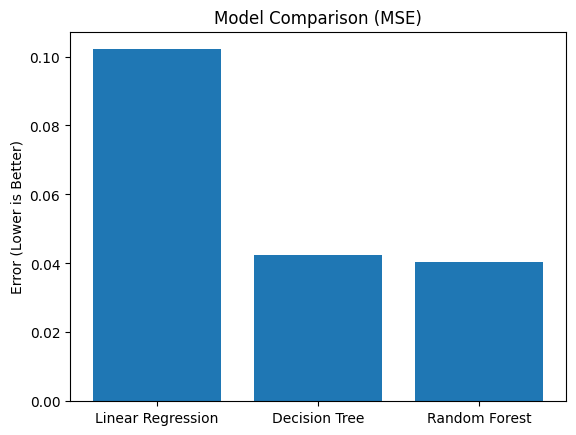

In [15]:
import matplotlib.pyplot as plt

plt.bar(models.keys(), models.values())
plt.title("Model Comparison (MSE)")
plt.ylabel("Error (Lower is Better)")
plt.show()

In [16]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [17]:
import os
print(os.listdir())

['model.pkl', 'social1.ipynb', 'Students Social Media Addiction.csv']


In [18]:
%matplotlib inline

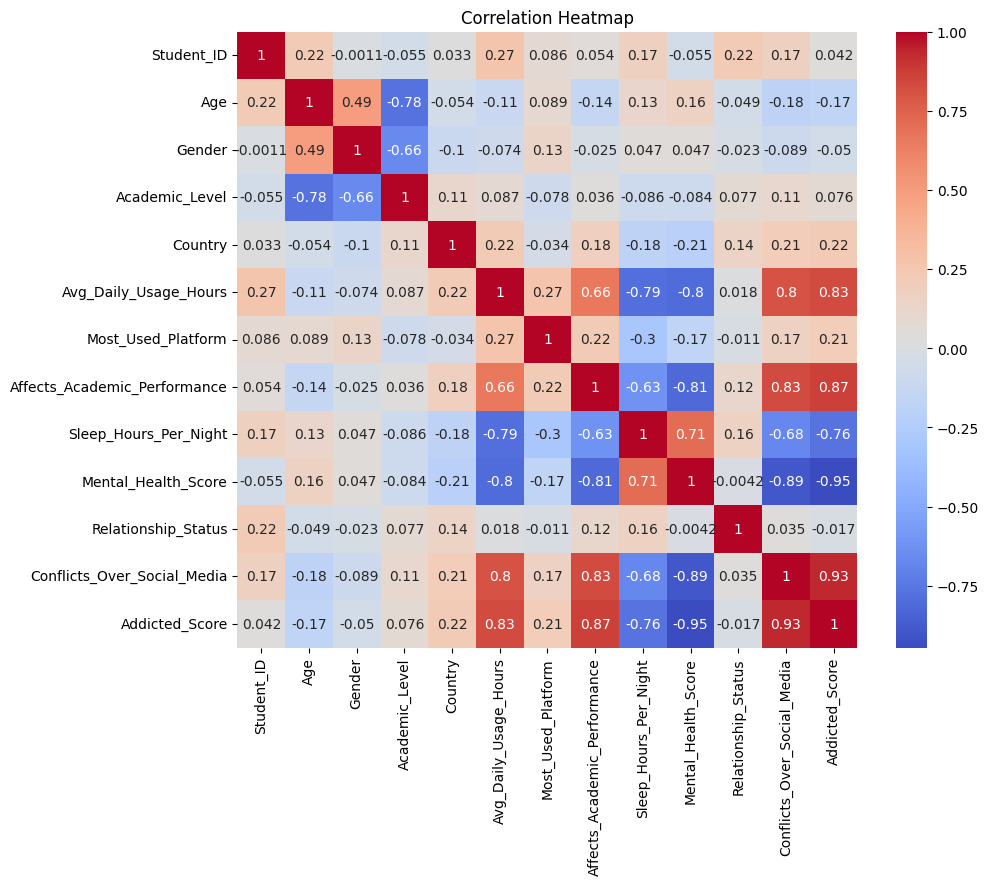

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

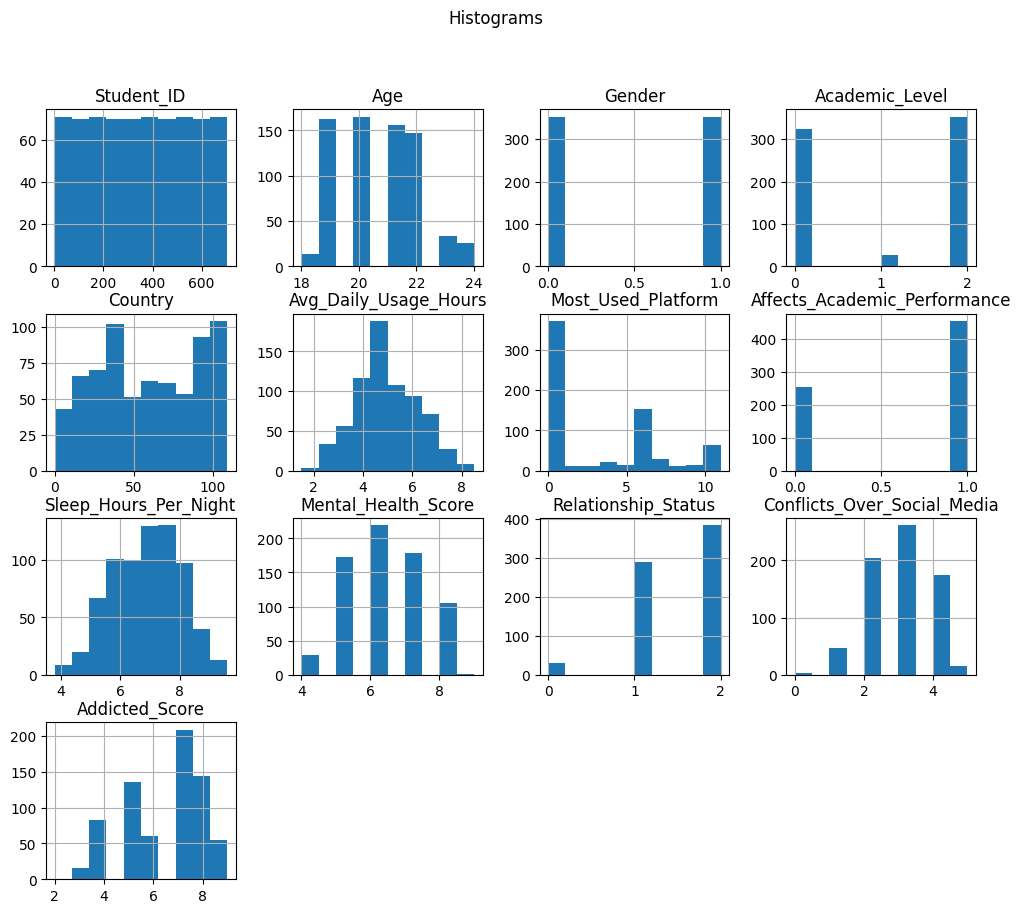

In [20]:
df.hist(figsize=(12,10))
plt.suptitle("Histograms")
plt.show()

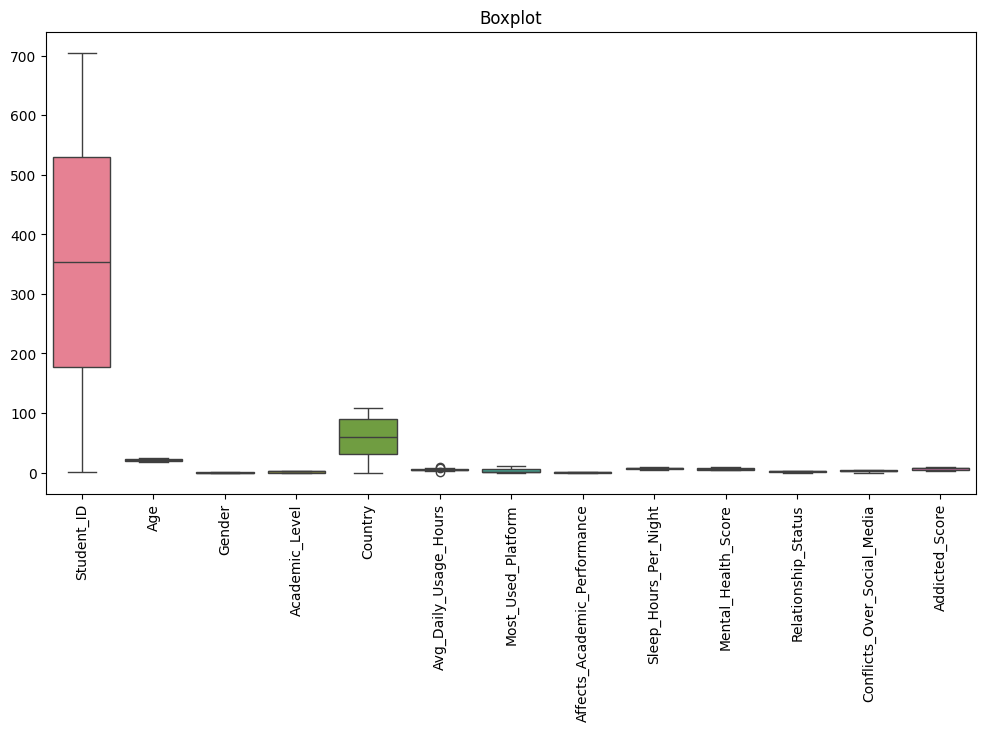

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot")
plt.show()

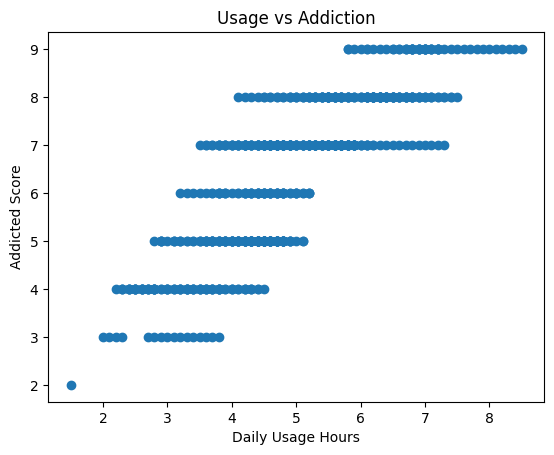

In [22]:
plt.scatter(df["Avg_Daily_Usage_Hours"], df["Addicted_Score"])
plt.xlabel("Daily Usage Hours")
plt.ylabel("Addicted Score")
plt.title("Usage vs Addiction")
plt.show()

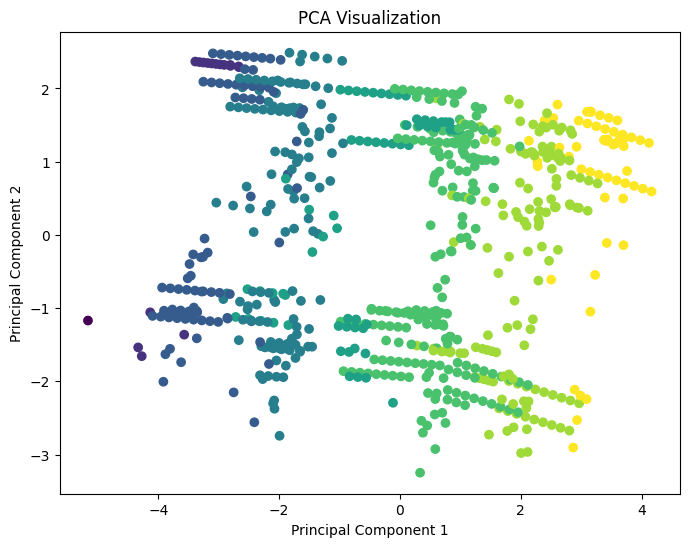

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()

In [24]:
print(pca.explained_variance_ratio_)

[0.35541118 0.1928407 ]


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

# Load dataset
df = pd.read_csv("Students Social Media Addiction.csv")

# Select only required features
features = ["Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Mental_Health_Score"]

X = df[features]
y = df["Addicted_Score"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Save model
pickle.dump(model, open("model.pkl", "wb"))

print(" Model trained and saved successfully!")

 Model trained and saved successfully!
